# Todesfälle nach Herkunft und Geschlecht

bev_todesfaelle_jahr_herkunft_geschlecht_od4201

### Kurzbeschreibung
Anzahl Todesfälle von Personen der wirtschaftlichen Wohnbevölkerung der Stadt Zürich, nach Herkunft, Geschlecht und Jahr..

Datum: 26.08.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_herkunft_geschlecht_od4201

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_herkunft_geschlecht_od4201


### Importiere die notwendigen Packages

In [110]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [111]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [112]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [113]:
#help(mypy_dv)
help(mypy_dl)

Help on module my_py_dataloading_functions:

NAME
    my_py_dataloading_functions

FUNCTIONS
    load_data(status, data_source, package_name, dataset_name, **kwargs)
        Diese Funktion importiert die gewünschten Daten je nach Status (Int/Prod) und Speicherort (Dropzone/Web) in Pandas ein.
        
        Parameter:
        - status (str): sind die Daten auf Integ ('int') oder auf Prod ('prod') zu beziehen? 
        - data_source (str): sind die Daten im Internet ('web'), LOSD ('ld') oder auf den Dropzones/Fileverzeichnis ('dropzone') zu beziehen?
        - package_name (str): Name des Packages. Dies entspricht dem Slug in der URL und auch dem Verzeichnisnamen auf der Dropzone. Z.B. 'bfs_bev_bildungsstand_seit1970_OD1002'
        - dataset_name (str): Name des Datensatzes (in CKAN der Ressource). z.B. "bev324od3242.csv"
        
        Optionale Parameter:
        - ckan_integ_url (str):  Pfad zur INT-Umgebung von CKAN. Default: 'https://data.integ.stadt-zuerich.ch/dataset/'
     

In [114]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [115]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [116]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [117]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

#### Paletten aus Zuericolors

In [118]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [119]:
package_name = "bev_todesfaelle_jahr_herkunft_geschlecht_od4201"

In [120]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV420OD4201"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_herkunft_geschlecht_od4201/download/BEV420OD4201.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_todesfaelle_jahr_herkunft_geschlecht_od4201 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_todesfaelle_jahr_herkunft_geschlecht_od4201 

data_source: web


In [121]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1971-01-01 00:00:00,1971-01-01 00:00:00
HerkunftCd,1,1
HerkunftLang,Schweizer*in,Schweizer*in
SexCd,1,2
SexLang,männlich,weiblich
AnzSterWir,2045,2055


Berechne weitere Attribute falls notwendig

In [122]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
HerkunftCd                      int64
HerkunftLang                   object
SexCd                           int64
SexLang                        object
AnzSterWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [123]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1971 und ein Maximumjahr von 2025


### Einfache Datentests

In [124]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 220 entries, 219 to 0
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      220 non-null    datetime64[ns]
 1   HerkunftCd           220 non-null    int64         
 2   HerkunftLang         220 non-null    object        
 3   SexCd                220 non-null    int64         
 4   SexLang              220 non-null    object        
 5   AnzSterWir           220 non-null    int64         
 6   StichtagDatJahr_str  220 non-null    object        
 7   Jahr                 220 non-null    datetime64[ns]
 8   Jahr_nbr             220 non-null    int32         
dtypes: datetime64[ns](2), int32(1), int64(3), object(3)
memory usage: 60.6 KB


In [125]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 220 rows (observations) and 9 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [126]:
data2betested.describe()

,StichtagDatJahr,HerkunftCd,SexCd,AnzSterWir,Jahr,Jahr_nbr
count,220,220,220,220,220,220
mean,1997-12-31 20:56:43.636363648,2,2,966,1997-12-31 20:56:43.636363648,1998
min,1971-01-01 00:00:00,1,1,111,1971-01-01 00:00:00,1971
25%,1984-01-01 00:00:00,1,1,166,1984-01-01 00:00:00,1984
50%,1998-01-01 00:00:00,2,2,699,1998-01-01 00:00:00,1998
75%,2012-01-01 00:00:00,2,2,1852,2012-01-01 00:00:00,2012
max,2025-01-01 00:00:00,2,2,2163,2025-01-01 00:00:00,2025
std,NaN,1,1,826,NaN,16


Welches sind die Quartiere ohne Werte bei BEW?

In [127]:
data2betested[np.isnan(data2betested.AnzSterWir)]

,StichtagDatJahr,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [128]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [129]:
data2betested.index.year.unique()

Index([1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985,
       1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [130]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [131]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftCd,SexCd,AnzSterWir,Jahr_nbr
count,220,220,220,220
mean,2,2,966,"1,998"
std,1,1,826,16
min,1,1,111,"1,971"
25%,1,1,166,"1,984"
50%,2,2,699,"1,998"
75%,2,2,"1,852","2,012"
max,2,2,"2,163","2,025"


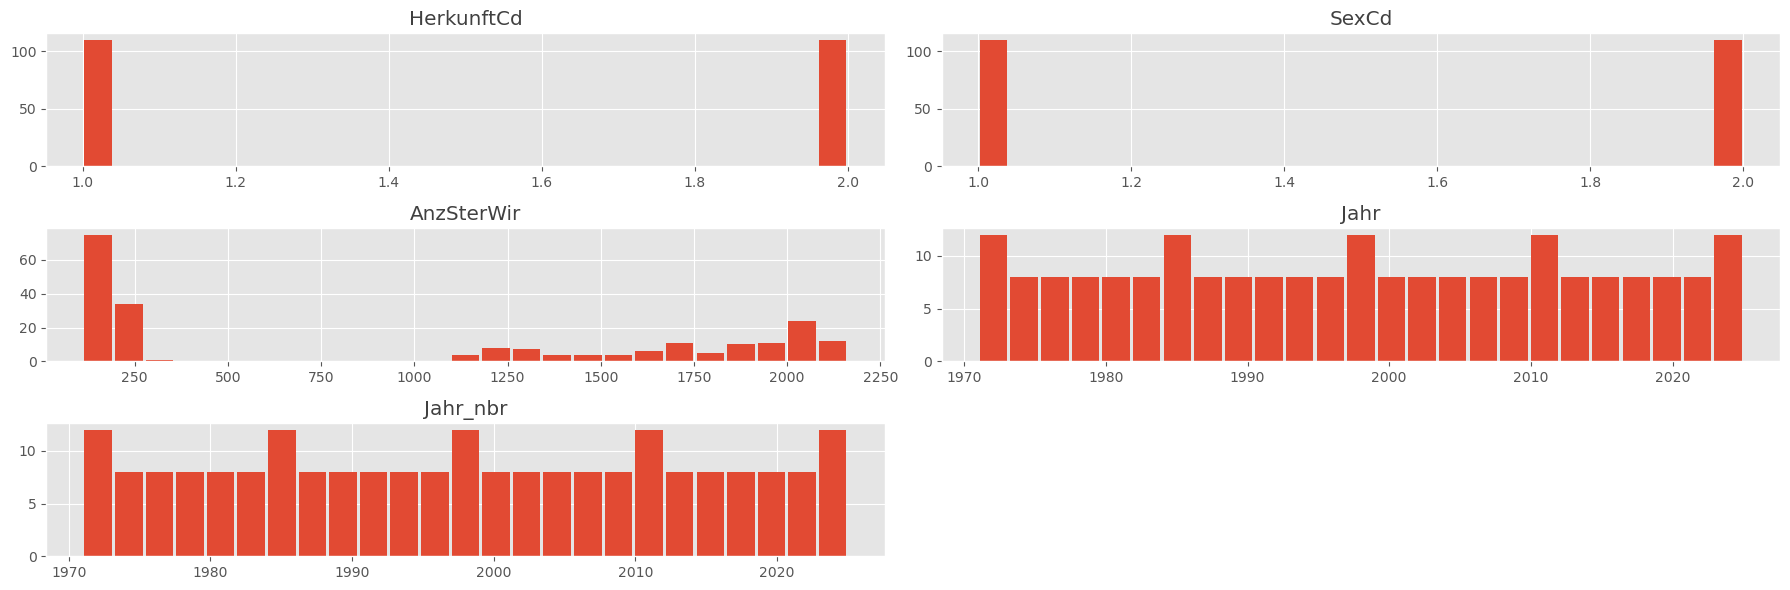

In [132]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [133]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,


### Nullwerte und Missings?

In [134]:
data2betested.isnull().sum()

HerkunftCd             0
HerkunftLang           0
SexCd                  0
SexLang                0
AnzSterWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_nbr               0
dtype: int64

In [135]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [136]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,sum_AnzSterWir
0,2025-01-01,2025,3043
1,2024-01-01,2024,3063
2,2023-01-01,2023,3106


In [137]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzSterWir
0,2,Ausländer*in,18964
1,1,Schweizer*in,193518


In [138]:
agg_sex = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['SexCd', 'SexLang']) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('SexCd', ascending=False) 
agg_sex.reset_index().head(3)

,SexCd,SexLang,sum_AnzSterWir
0,2,weiblich,112693
1,1,männlich,99789


In [139]:
data2betested.reset_index().columns

Index(['StichtagDatJahr', 'HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang', 'AnzSterWir',
       'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [140]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,HerkunftCd,HerkunftLang,SexCd,SexLang,AnzSterWir,StichtagDatJahr_str,Jahr,Jahr_nbr
StichtagDatJahr,,,,,,,,
2025-01-01,1,Schweizer*in,1,männlich,1118,2025-01-01,2025-01-01,2025
2025-01-01,1,Schweizer*in,2,weiblich,1491,2025-01-01,2025-01-01,2025


### Visualisierungen nach Zeitausschnitten

#### Entwicklung der Todesfälle

In [141]:
data2betested.columns

Index(['HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang', 'AnzSterWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_nbr'],
      dtype='object')

In [142]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'HerkunftCd', 'HerkunftLang',]) \
    .agg(sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,HerkunftCd,HerkunftLang,sum_AnzSterWir
0,1971-01-01,1,Schweizer*in,4100
1,1971-01-01,2,Ausländer*in,340
2,1972-01-01,1,Schweizer*in,3949


In [143]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('HerkunftCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_AnzSterWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    , custom_palette=[zuericolors_qual12br[0], zuericolors_qual12br[4]]
    ,myTitle="Entwicklung Todesfälle nach Herkunft, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Geschlecht

In [144]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg2 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'SexLang', 'SexCd']) \
    .agg(sum_WBev=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg2.reset_index().head(3)

,StichtagDatJahr,SexLang,SexCd,sum_WBev
0,1971-01-01,männlich,1,2224
1,1971-01-01,weiblich,2,2216
2,1972-01-01,männlich,1,2165


In [145]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().sort_values('SexCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "SexLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,custom_palette=[zuericolors_gender3[0], zuericolors_gender3[2]]
    ,myTitle="Entwicklung Todesfälle nach Geschlecht, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [146]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

In [154]:
myAggBar1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','HerkunftCd', 'HerkunftLang', 'Jahr_nbr']) \
    .agg(Sum_AnzSterWir=('AnzSterWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAggBar1.reset_index().head(3)

,StichtagDatJahr,HerkunftCd,HerkunftLang,Jahr_nbr,Sum_AnzSterWir
0,1971-01-01,1,Schweizer*in,1971,4100
1,1971-01-01,2,Ausländer*in,1971,340
2,1972-01-01,1,Schweizer*in,1972,3949


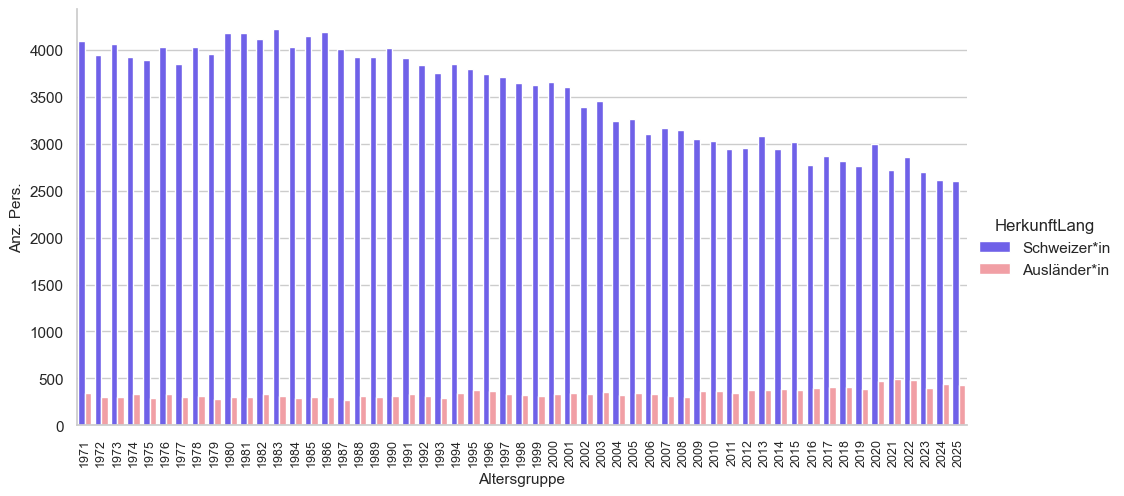

In [164]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Jahr_nbr"
            , y="Sum_AnzSterWir"
            , hue="HerkunftLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette=[zuericolors_qual12br[0],zuericolors_qual12br[5]] #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar1.reset_index()
           )
myHist.set_xticklabels(rotation=90, fontsize=9) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


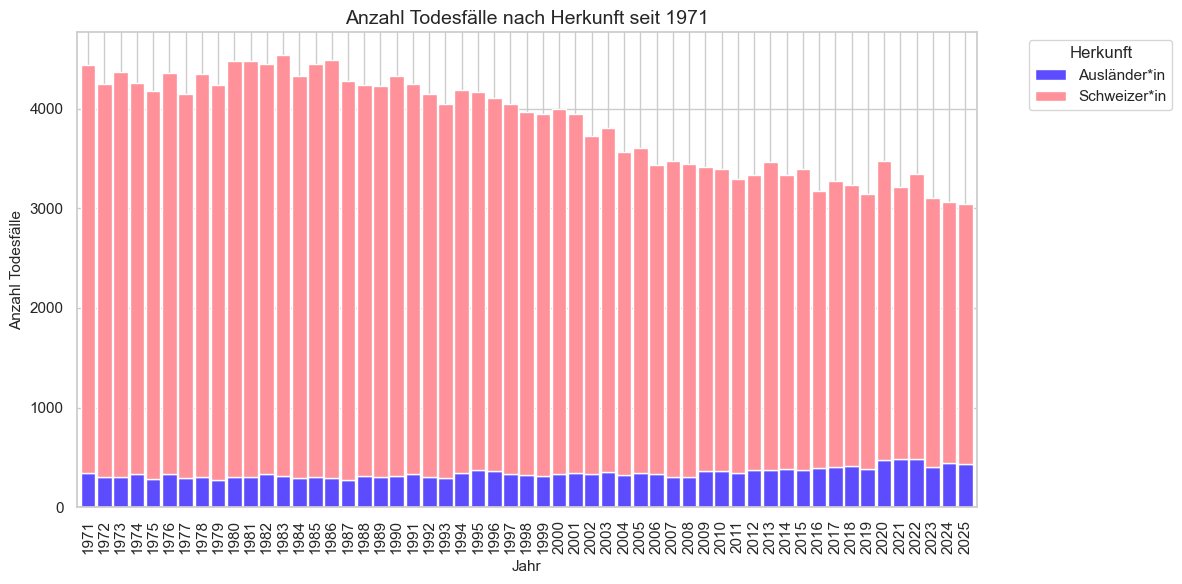

In [ ]:
# Daten vorbereiten

data = myAggBar.query("Sum_AnzSterWir > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='HerkunftLang', values='Sum_AnzSterWir').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette([zuericolors_qual12br[0],zuericolors_qual12br[5]], n_colors=len(data_pivoted.columns)) #"cubehelix" / "flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Anzahl Todesfälle nach Herkunft seit '+data_min_date, fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Anzahl Todesfälle', fontsize=11)

# Legende anpassen
plt.legend(title='Herkunft', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Faced Grids

In [171]:
data2betested.columns

Index(['HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang', 'AnzSterWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_nbr'],
      dtype='object')

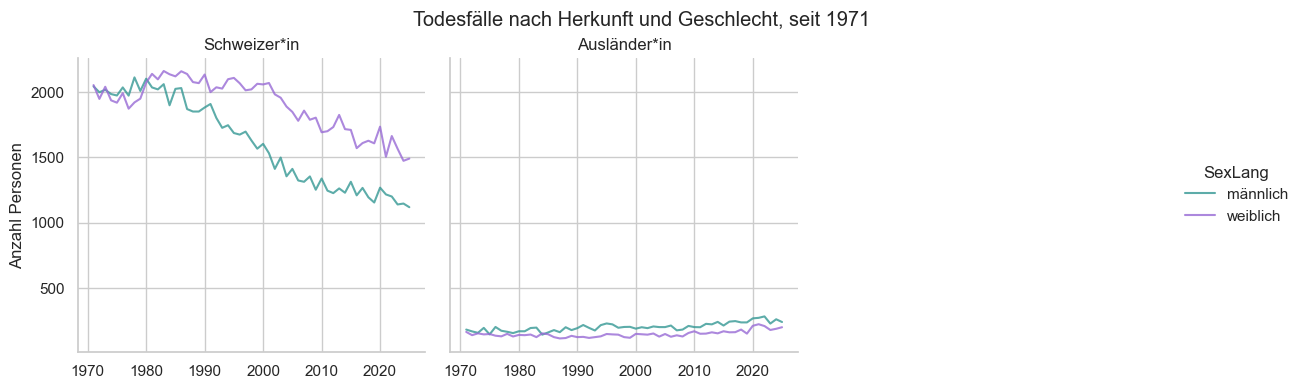

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('HerkunftCd', ascending=True)
    ,col = "HerkunftLang"
    ,hue = "SexLang"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzSterWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,palette=[zuericolors_gender3[0], zuericolors_gender3[2]]
    ,height = 3
    ,myTitle="Todesfälle nach Herkunft und Geschlecht, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

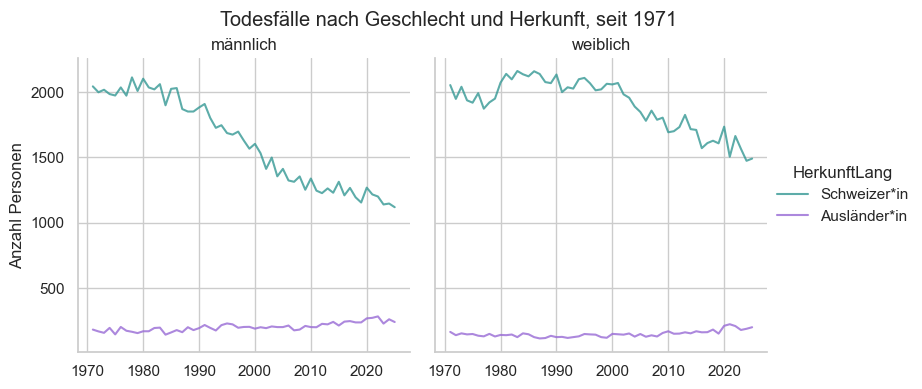

In [178]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = data2betested.reset_index().sort_values('SexCd', ascending=True)
    ,col = "SexLang"
    ,hue = "HerkunftLang"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzSterWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,palette=[zuericolors_gender3[0], zuericolors_gender3[2]]
    ,height = 3
    ,myTitle="Todesfälle nach Geschlecht und Herkunft, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

In [180]:
data2betested.columns

Index(['HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang', 'AnzSterWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_nbr'],
      dtype='object')

In [190]:
# Extrahiere die Top-Fahrzeugmarken
attr2becolored = data2betested['HerkunftLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12br

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Schweizer*in': '#5D4BFE', 'Ausländer*in': '#4AA9FF'}


##### Todesfälle nach Herkunft und Geschlecht

In [191]:
data2betested.columns

Index(['HerkunftCd', 'HerkunftLang', 'SexCd', 'SexLang', 'AnzSterWir', 'StichtagDatJahr_str',
       'Jahr', 'Jahr_nbr'],
      dtype='object')

In [192]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index().query("AnzSterWir>0")
    ,levels=['Jahr_nbr','HerkunftLang','SexLang']
    ,values="AnzSterWir"
    ,color="AnzSterWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit, seit "+data_min_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001E50E8BB950>, 'Jahr_nbr', 'HerkunftLang', 'SexLang']
Typ von path: <class 'list'>


In [193]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=data2betested.reset_index().query("AnzSterWir>0")
    ,levels=['Jahr_nbr','HerkunftLang','SexLang',]
    ,values="AnzSterWir"
    ,color="HerkunftLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Todesfälle nach Altersgruppe, Geschlecht, Herkunft und Todesörtlichkeit, seit "+data_min_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000001E514D61710>, 'Jahr_nbr', 'HerkunftLang', 'SexLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1433&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3DPageView%253DPersonal%2DShowWebPart%253D%257B6087A3E7%2D%2D8AC8%2D%2D40BA%2D%2D8278%2D%2DDECFACE124FF%257D%2DSortField%253DCreated%2DSortDir%253DAsc&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------